In [1]:
# Install necessary packages to Project environment in terminal
# Check that they have been precompiled by running the following:
using Pkg;Pkg.status()

      Status `~/work/washington/jup_moons/Project.toml`
  [1537fe66] CALCEPH v1.1.0 `~/.julia/dev/CALCEPH`
  [7073ff75] IJulia v1.23.3
  [42fd0dbc] IterativeSolvers v0.9.2
  [2fda8390] LsqFit v0.13.0
  [91a5bcdd] Plots v1.40.20
  [438e738f] PyCall v1.94.1
  [d330b81b] PyPlot v2.11.0
  [5bab7191] SPICE v0.2.2
  [d84f081e] TTVFaster v0.1.1
  [8bb1440f] DelimitedFiles
  [37e2e46d] LinearAlgebra
  [9a3f8284] Random
  [10745b16] Statistics


In [2]:
include("sim_times.jl")

calc_obs_loc (generic function with 1 method)

## Create data.
Integrate orbits from JPL Epheremis

In [3]:
nyear=2.0
jd_start=2443000.0; 
jd_end=jd_start + nyear*365.25; 
jdsize=1000
times=range(jd_start, stop=jd_end, length=jdsize)

AU = 149597870.700 #km
# dt = (jd2 - jd1)/jdsize
# @assert (jd_start >= 2287184.5) #2414105.0
# @assert (jd_end <= 2688976.5) #2488985.0
# function get_vectors()
options = useNaifId+unitKM+unitSec # useNaifId + unitDay + unitAU
# Compute ephemerides (positions, velocities, and accelerations) of Galilean Moons:
# positions = pva[1:3] ; velocities = pva[4:6]; accel = pva[6:9]
pos = zeros(3,4,jdsize)
vel = zeros(3,4,jdsize)
acc = zeros(3,4,jdsize)
moon_ids = [naifId.id[:io],naifId.id[:europa],naifId.id[:ganymede],naifId.id[:callisto]]
for i=1:length(times)
    for j=1:4
        pva= compute(eph,times[i],0.0,moon_ids[j],naifId.id[:jupiter],
            options,2)
        pos[:,j,i].=pva[1:3]
        vel[:,j,i].=pva[4:6]
        acc[:,j,i].=pva[7:9]
    end
end
#     return pos,vel,acc
# end

In [4]:
using PyPlot
plt.style.available;
obj_names=["Io","Eur","Gan","Cal"]
co_cycle=plt.cycler("color",["#FD8595","#FF8D5D","#F358AA","#FCB7DB"])

'#FD8595'
'#FF8D5D'
'#F358AA'
'#FCB7DB'


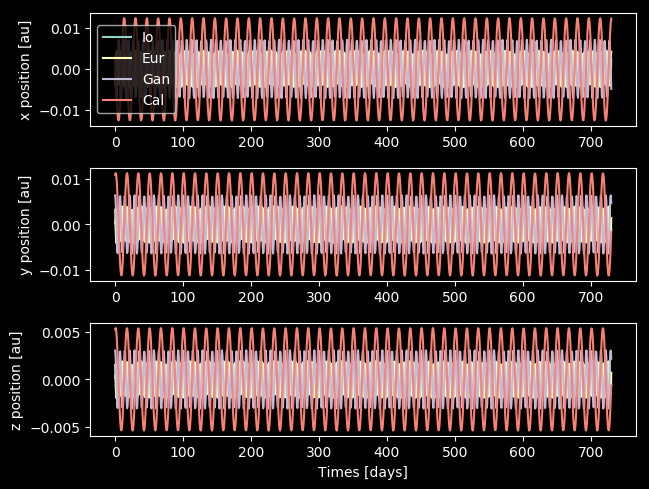

PyObject Text(0.5, 24.0, 'Times [days]')

In [5]:
using PyPlot
plt.style.use("dark_background")
mean_sma=[422e3,671e3,1070e3,1883e3]
# fig,(axes)=subplots(2,2,figsize=(8,6),sharex=true,sharey=true)
fig,(ax,ax2,ax3)=subplots(3)
# ax.set_prop_cycle(co_cycle)
for i=1:4
#     axes[i].axhline(mean_sma[i],ls="--",label="avg semi-major axis")
    ax.plot(collect(times).-times[1],pos[1,i,:]./AU,label=obj_names[i])
    ax2.plot(collect(times).-times[1],pos[2,i,:]./AU,label=obj_names[i])
    ax3.plot(collect(times).-times[1],pos[3,i,:]./AU,label=obj_names[i])
end
fig.tight_layout()
ax.legend()
ax.set_ylabel("x position [au]");ax2.set_ylabel("y position [au]");ax3.set_ylabel("z position [au]");
ax3.set_xlabel("Times [days]")

Find the observer location required to see Io and Europa transiting Jupiter

In [6]:
n_obs=calc_obs_loc(pos[:,1,1],vel[:,1,1],pos[:,2,1],vel[:,2,1])

3-element Vector{Float64}:
  0.26004303781396526
 -0.873091415719677
 -0.41241847470875376

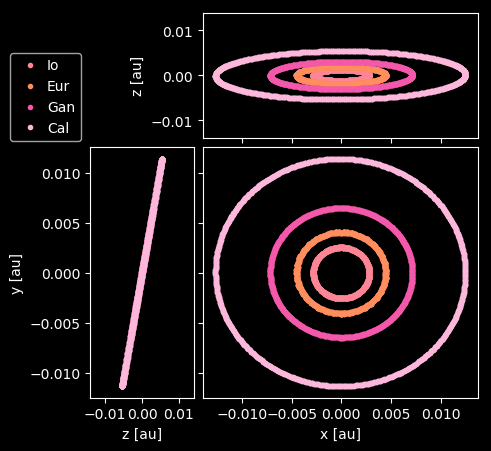

PyObject <matplotlib.legend.Legend object at 0x7ff777ede780>

In [7]:
fig=figure(figsize=(5,5))
# ax=fig.add_subplot(111)
# ax1=plt.subplot2grid((2,2),(0,0),rowspan=2)
# ax3=plt.subplot2grid((2,2),(1,0))
plt.style.use("dark_background")
gs = fig.add_gridspec(2, 2, width_ratios=(1.5, 4), 
                            height_ratios=(1, 2),wspace=0.05, hspace=0.05)
ax1 = fig.add_subplot(gs[2, 2])
ax2 = fig.add_subplot(gs[1, 2])
ax3 = fig.add_subplot(gs[2, 1])
ax1.set_prop_cycle(co_cycle)
ax2.set_prop_cycle(co_cycle)
ax3.set_prop_cycle(co_cycle)

for i=1:4
    ax1.plot(pos[1,i,:]./AU,pos[2,i,:]./AU,label=obj_names[i],".")
    ax2.plot(pos[1,i,:]./AU,pos[3,i,:]./AU,".")
    ax3.plot(pos[3,i,:]./AU,pos[2,i,:]./AU,".")
end
axes_limit = 1.1* maximum(abs.(pos[:,:,:]./AU))
ax2.set_ylim(-axes_limit,axes_limit);ax3.set_xlim(-axes_limit,axes_limit);
ax2.tick_params(labelbottom=false);ax1.tick_params(labelleft=false)
ax1.set_xlabel("x [au]");ax2.set_ylabel("z [au]")
ax3.set_xlabel("z [au]");ax3.set_ylabel("y [au]");
fig.legend(bbox_to_anchor=(0.075,0.705,0.10,.105),handletextpad=.25)
# # plot(n_obs[1].*range(0,stop=0.01,length=100),n_obs[2].*range(0,stop=0.01,length=100))

# # ax1.plot([0,n_obs[1]],[0,n_obs[2]],"k--",linewidth=1,alpha=0.5,zorder=1)
# # ax1.annotate(L"\sphericalangle",xy=[0.195;1.015],xycoords="data",fontsize="medium",rotation=-104.37) 

Find observed transit time $t_{obs}$ (O) using JPL Ephemeris simulations 
(assuming that moons are co-planar, and from same observer)

In [43]:
# observed transit times: 
tt_IO=transit_times(naifId.id[:io],eph,times,1.769,1.0,n_obs,10);
tt_EUR=transit_times(naifId.id[:europa],eph,times,3.551,1.0,n_obs,10);
tt_GAN=transit_times(naifId.id[:ganymede],eph,times,7.155,1.0,n_obs,10);
tt_CAL=transit_times(naifId.id[:callisto],eph,times,16.69,1.0,n_obs,10);

## Add Gaussian noise

In [44]:
# add some level of Gaussian error: (assume same error for all moons)
sigIO,noiseIO=fixed_noise(tt_IO,30);
sigEUR,noiseEUR=fixed_noise(tt_EUR,30);
sigGAN,noiseGAN=fixed_noise(tt_GAN,30);
sigCAL,noiseCAL=fixed_noise(tt_CAL,30);

In [65]:
noise = [noiseIO;noiseEUR;noiseGAN;noiseCAL];

In [60]:
tt_IO[1:5].-jd_start

5-element Vector{Float64}:
 1.3746256758458912
 3.14371260907501
 4.912811203394085
 6.681904025841504
 8.451023916713893

Perform linear regression, given guess of period from median of transit times

In [45]:
using Statistics
P1_est = median(diff(tt_IO))
P2_est = median(diff(tt_EUR))
P3_est = median(diff(tt_GAN))
P4_est = median(diff(tt_CAL))
println("Period Estimates:")
println(P1_est,'\n',P2_est,'\n',P3_est,'\n',P4_est)

Period Estimates:
1.7691396507434547
3.5510498746298254
7.154473674949259
16.68904782552272


In [11]:
#Period values from PlanetBodyData.pdf
# 1.769
# 3.551
# 7.155
# 16.69

In [46]:
x_io,t0_io,per_io=linear_fit(tt_IO+noiseIO,1.769,sigIO)
x_eur,t0_eur,per_eur=linear_fit(tt_EUR+noiseEUR,3.551,sigEUR)
x_gan,t0_gan,per_gan=linear_fit(tt_GAN+noiseGAN,7.155,sigGAN)
x_cal,t0_cal,per_cal=linear_fit(tt_CAL+noiseCAL,16.69,sigCAL)

([1.0 1.0 … 1.0 1.0; 0.0 1.0 … 42.0 43.0], 2.443009798252891e6, 16.689047820919335)

In [13]:
x_io[:,:] # print to check epochs/transit numbers

2×413 Matrix{Float64}:
 1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  …    1.0    1.0    1.0    1.0    1.0
 0.0  1.0  2.0  3.0  4.0  5.0  6.0  7.0     408.0  409.0  410.0  411.0  412.0

In [47]:
tt0=[t0_io;t0_eur;t0_gan;t0_cal].-jd_start

4-element Vector{Float64}:
 1.3755543031729758
 1.5741187408566475
 3.754149849526584
 9.798252890817821

In [69]:
println("Period from regression:")
per = [per_io, per_eur,per_gan, per_cal]

Period from regression:


4-element Vector{Float64}:
  1.7691389060563687
  3.55117209710988
  7.154556316608626
 16.689047820919335

## Inspect period ratios

In [70]:
println("Period Ratios:")
for i =1:4
    for j = i:4
        if i != j
        println(obj_names[i],"-",obj_names[j]," ratio: ",per[j]/per[i])
    end
end
end

Period Ratios:
Io-Eur ratio: 2.007288452564692
Io-Gan ratio: 4.044089637120142
Io-Cal ratio: 9.433429881501675
Eur-Gan ratio: 2.014702785717245
Eur-Cal ratio: 4.6995885765439835
Gan-Cal ratio: 2.332646090460884


Period ratios for Io-Europa-Ganymede are near integer values (1:2:4). Close to resonances, a combination of changes in semi-major axis and eccentricity leads to TTV cycles whose periods depend on the seperation from resonance.

In [48]:
# transit number (or Epoch) is second column of x
nt_io=x_io[2,:]
nt_eur=x_eur[2,:]
nt_gan=x_gan[2,:]
nt_cal=x_cal[2,:];

Compute calculted linear transit times (C) assuming constant period (i.e. the linear empheris)

$t_{calc} = t_{0} + Per \times E$  

In [49]:
tt0_IO  = collect(t0_io .+ per_io .* range(0,stop=length(tt_IO)-1,length=length(tt_IO))) ;
tt0_EUR  = collect(t0_eur .+ per_eur .* range(0,stop=length(tt_EUR)-1,length=length(tt_EUR))) ;
tt0_GAN  = collect(t0_gan .+ per_gan .* range(0,stop=length(tt_GAN)-1,length=length(tt_GAN))) ;
tt0_CAL  = collect(t0_cal .+ per_cal .* range(0,stop=length(tt_CAL)-1,length=length(tt_CAL))) ;

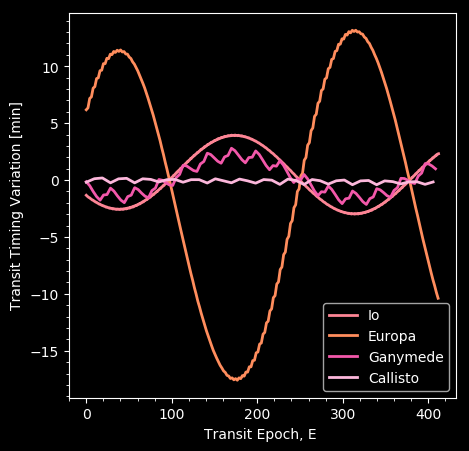

In [71]:
# rc("font",family="sans-serif")
fig,ax=subplots(1,figsize=(5,5))
ax.set_prop_cycle(co_cycle)
ax.plot((tt_IO.-t0_io)/per_io,(tt_IO.-tt0_IO).*24*60,label="Io",lw=2)
ax.plot((tt_EUR.-t0_eur)/per_io,(tt_EUR.-tt0_EUR).*24*60,label="Europa",lw=2)
ax.plot((tt_GAN.-t0_gan)/per_io,(tt_GAN.-tt0_GAN).*24*60,label="Ganymede",lw=2)
ax.plot((tt_CAL.-t0_cal)/per_io,(tt_CAL.-tt0_CAL).*24*60,label="Callisto",lw=2)
ax.set_xlabel("Transit Epoch, E ")
ax.set_ylabel("Transit Timing Variation [min]")
ax.legend()
ax.minorticks_on()

Io, Europa, and Ganymede vary on same timescale (the fact that all three vary together is related to the Laplace resonance) as expected for pairs of planetary satellites.

TTVs of Io and Ganymede are anti-correlated with those of Europa (conservation of energy within the system)

TTVs on Europa are larger than others because Io and Ganymede (it's adjacent bodies) are more massive than Europa.

Callisto's TTVs are on a longer timescale (Q: why?)

In [72]:
println("Semi-amplitude of transit time variations (i.e. maximum absolute value)")
println("Io: ",maximum(abs.(tt_IO.-tt0_IO).*24*60))
println("Europa: ",maximum(abs.(tt_EUR.-tt0_EUR).*24*60))
println("Ganymede: ",maximum(abs.(tt_GAN.-tt0_GAN).*24*60))
println("Callisto: ",maximum(abs.(tt_CAL.-tt0_CAL).*24*60))

Semi-amplitude of transit time variations (i.e. maximum absolute value)
Io: 3.9547502249479294
Europa: 17.590562403202057
Ganymede: 2.793019786477089
Callisto: 0.41403114795684814


want minimum of $\chi^2 \equiv \sum \frac{(t_{model} - t_{obs})^2}{\sigma^2}$

- Save cartesian positions and velocities. 
- Save data with transiting body, ntrans, transit time, and transit time errors.

In [50]:
# tt=[tt_IO;tt_EUR;tt_GAN;tt_CAL]
# sigtt=[sigIO;sigEUR;sigGAN;sigCAL];
tt=[tt_IO+noiseIO;tt_EUR+noiseEUR;tt_GAN+noiseGAN;tt_CAL+noiseCAL].-jd_start
sigtt=[sigIO;sigEUR;sigGAN;sigCAL]
tt0=[tt0_IO;tt0_EUR;tt0_GAN;tt0_CAL].-jd_start
nt1,nt2,nt3,nt4=length(tt_IO),length(tt_EUR),length(tt_GAN),length(tt_CAL)

(413, 206, 102, 44)

In [67]:
noise_free_tt = [tt_IO;tt_EUR;tt_GAN;tt_CAL].- jd_start
isapprox(tt .- noise,noise_free_tt)

true

In [66]:
body = zeros((nt1+nt2+nt3+nt4))
body[1:nt1] .= 1.0
body[nt1+1:nt1+nt2] .= 2.0
body[nt1+nt2+1:nt1+nt2+nt3].= 3.0
body[nt1+nt2+nt3+1:end] .= 4.0;
linear_epochs = [nt_io;nt_eur;nt_gan;nt_cal];

In [68]:
#=
name="galileo_moons_data_noiseless.txt"
println("Create ",name)
open(name,"w+") do io
    println(io,"Orbits integrated with JPL ephemerides, version jup365.bsp starting at $jd_start .")

println(io,"These true transit times include no white noise.")
println(io,"#body",'\t',"ntrans",'\t',"tt")
    for i=1:length(tt)
      println(io,body[i],'\t',linear_epochs[i],'\t',noise_free_tt[i],)
    end
end
=#

Create galileo_moons_data_noiseless.txt


In [23]:
info=["Positions, Velocities and Acceleration arrays.
    Units are [AU] , [AU/day], [AU/day^2]"]

1-element Vector{String}:
 "Positions, Velocities and Acceleration arrays.\n    Units are [AU] , [AU/day], [AU/day^2]"

In [390]:
using JLD2
#=
@save "jup_moon_cartesians.jld2" info times pva_IO pva_EUR pva_GAN pva_CAL
=#

In [358]:
#=
name="galileo_moons_data.txt"
println("Create ",name)
open(name,"w+") do io
    println(io,"Orbits integrated with JPL ephemerides, version jup365.bsp starting at $jd_start .")

println(io,"The synthetic times include Normally sampled noise with zero mean and 30 second standard deviation.")
println(io,"#body",'\t',"ntrans",'\t',"tt",'\t',"sigtt")
    for i=1:length(tt)
      println(io,body[i],'\t',linear_epochs[i],'\t',tt[i],'\t',sigtt[i])
    end
end
=#

Create galileo_moons_data.txt


## Fit all four moons

In [73]:
using TTVFaster
p1=TTVFaster.Planet_plane_hk((3e-5),per_io,t0_io.-jd_start,0.01,0.01)
p2=TTVFaster.Planet_plane_hk((3e-5),per_eur,t0_eur.-jd_start,0.01,0.01)
p3=TTVFaster.Planet_plane_hk((3e-5),per_gan,t0_gan.-jd_start,0.01,0.01)
p4=TTVFaster.Planet_plane_hk((3e-5),per_cal,t0_cal.-jd_start,0.01,0.01)

Planet_plane_hk{Float64}(3.0e-5, 16.689047820919335, 9.798252890817821, 0.01, 0.01)

In [74]:
# Okay,now let's do a 4-moon fit:
# param_names = mass ratio,period,initial transit time,e*cos(omega),e*sin(omega)
init_param = [(3e-5),per_io,t0_io.-jd_start,0.01,0.01,
            (3e-5),per_eur,t0_eur.-jd_start,0.01,0.01,
            (3e-5),per_gan,t0_gan.-jd_start,0.01,0.01,
            (3e-5),per_cal,t0_cal.-jd_start,0.01,0.01]
println("Initial parameters: ",init_param)

Initial parameters: [3.0e-5, 1.7691389060563687, 1.3755543031729758, 0.01, 0.01, 3.0e-5, 3.55117209710988, 1.5741187408566475, 0.01, 0.01, 3.0e-5, 7.154556316608626, 3.754149849526584, 0.01, 0.01, 3.0e-5, 16.689047820919335, 9.798252890817821, 0.01, 0.01]


In [75]:
using TTVFaster
# Set up data structure to hold planet properties,passed to TTVFaster
jmax = 5
data=init_param
p1=TTVFaster.Planet_plane_hk(data[1],data[2],data[3],data[4],data[5])
p2=TTVFaster.Planet_plane_hk(data[6],data[7],data[8],data[9],data[10])
p3=TTVFaster.Planet_plane_hk(data[11],data[12],data[13],data[14],data[15])
p4=TTVFaster.Planet_plane_hk(data[16],data[17],data[18],data[19],data[20])
# assuming no transits are skipped/duplicated ########### To Change
time1 = collect(p1.trans0 .+ range(0,stop=nt1-1,length=nt1) .* p1.period)
time2 = collect(p2.trans0 .+ range(0,stop=nt2-1,length=nt2) .* p2.period)
time3 = collect(p3.trans0 .+ range(0,stop=nt3-1,length=nt3) .* p3.period)
time4 = collect(p4.trans0 .+ range(0,stop=nt4-1,length=nt4) .* p4.period)
##########
# Initialize the computation of the Laplace coefficients:
ttv1 = zeros(nt1)
ttv2 = zeros(nt2)
ttv3 = zeros(nt3)
ttv4 = zeros(nt4)
# # Need first call to TTVFaster,without optimizing; Q: why?
dummy=TTVFaster.compute_ttv!(jmax,p1,p2,time1,time2,ttv1,ttv2)

In [76]:
function new_wrapper(tt0::Vector{Float64},nplanet::Int64,ntrans::Vector{Int64},
        params::Vector{T},jmax::Integer=5) where T<:Real
  # These lines need modification for different choices of parameters:
  n1,n2,n3,n4 = ntrans[1:4]
  # println(n1, " ", n2)

  # Call ttv_nplanet:
  ttv = TTVFaster.ttv_nplanet(nplanet,jmax,ntrans,params[1:5*nplanet])
  # We measure transit times,not TTVs,so add back in the linear ephemeris:
  per1 = params[2]; t01 = params[3]
  tt1 = collect(range(t01,stop = t01+per1*(n1-1),length = n1)) 
  for i=1:n1
    tt1[i]+= ttv[1,i]
  end
  per2 = params[7];  t02 = params[8]
  tt2 = collect(range(t02,stop = t02+per2*(n2-1),length = n2)) 
  for i=1:n2
    tt2[i] += ttv[2,i]
  end
  per3 = params[12];  t03 = params[13]
  tt3 = collect(range(t03,stop = t03+per3*(n3-1),length = n3)) 
  for i=1:n3
    tt3[i] += ttv[3,i]
  end
  per4 = params[17];  t04 = params[18]
  tt4 = collect(range(t04,stop = t04+per4*(n4-1),length = n4)) 
  for i=1:n4
    tt4[i] += ttv[4,i]
  end
  # If transit times of additional planets were observable these would need to be added in.
  return [tt1;tt2;tt3;tt4]  
end


function chisquare(tt0,nplanet,ntrans,params,tt,sigtt,jmax,return_ttmodel=false)
  chisq = 0.0  
    
  # println(params,tt[1],sigtt[1])
  tt_model = new_wrapper(tt0,nplanet,ntrans,params,jmax)
#println(length(tt_model))
  for j=1:length(tt)
    chisq += (tt[j]-tt_model[j])^2/sigtt[j]^2
  end
    if return_ttmodel
  return chisq, tt_model
        else 
        return chisq
    end
end

chisquare (generic function with 2 methods)

In [77]:
chi2,ttmodel=chisquare(tt0,4,[nt1,nt2,nt3,nt4],init_param,tt,sigtt,5,true)

(860170.768986807, [1.3604230849507983, 3.129468844990823, 4.8985338443162485, 6.667596661585057, 8.436684619128258, 10.205760981000982, 11.974859400042089, 13.74395273747775, 15.513074793946743, 17.282182796380198  …  577.2259691064274, 593.9149278973266, 610.6038898003357, 627.2931194244044, 643.9820366149938, 660.6710772846237, 677.3602359827222, 694.0491864737965, 710.7382182441702, 727.4273904326687])

In [78]:
using LsqFit
weight = ones(nt1+nt2+nt3+nt4)./ sigtt.^2 #assigns each data point stat weight d.t. noise = 1/σ^2
param1 = init_param .+ 100.0
niter = 0
while maximum(abs.(param1 .- init_param)) > 1e-5 && niter < 20
    param1 = init_param
    res = curve_fit((tt0,params) -> new_wrapper(tt0,4,[nt1,nt2,nt3,nt4],params,jmax),tt0,tt,weight,init_param)
    init_param = res.param
    niter += 1
    # println("init_param: ",init_param)
    println("New Initial chi-square: ",chisquare(tt0,4,[nt1,nt2,nt3,nt4],init_param,tt,sigtt,jmax))
end
println("New initial fit: ",init_param," in ",niter," iterations.")

New Initial chi-square: 697.4271094463325
New Initial chi-square: 697.4271094454479
New initial fit: [0.00010889328032298237, 1.7691379326784136, 1.376131115144384, -0.0002850807926667969, 0.0012423107544919723, 2.7649082850079688e-5, 3.5511811007621454, 1.5715054139497764, 0.0009707593477381093, 0.003303088737938682, 8.428576241841986e-5, 7.154553960086175, 3.7544798712296426, 0.0039303852981230035, 0.009246755719435498, 5.521983328393051e-5, 16.689047441920724, 9.79826341144936, 0.01119906231236957, 0.02717170100877328] in 2 iterations.


In [80]:
fitted_param=init_param

20-element Vector{Float64}:
  0.00010889328032298237
  1.7691379326784136
  1.376131115144384
 -0.0002850807926667969
  0.0012423107544919723
  2.7649082850079688e-5
  3.5511811007621454
  1.5715054139497764
  0.0009707593477381093
  0.003303088737938682
  8.428576241841986e-5
  7.154553960086175
  3.7544798712296426
  0.0039303852981230035
  0.009246755719435498
  5.521983328393051e-5
 16.689047441920724
  9.79826341144936
  0.01119906231236957
  0.02717170100877328

In [217]:
fitted_param_nonoise=[2.2126043976578172e-5, 1.7691379502481228, 2.4430013761121123e6, 0.007751751099312117, 0.005628408764951272, 8.11786379650111e-6, 3.5511794691007053, 2.4430015717005776e6, 0.01155460383822889, 0.014496948831622699, 1.6575952371914217e-5, 7.154553873323255, 2.443003754494242e6, 0.025112483878938364, 0.03932104352551073, 3.6193228266045786e-5, 16.68904360825258, 2.443009798274682e6, -0.010126857401793858, 0.07011702571589983]# in 174 iterations.
# with New Initial chi-square: 34.559731294835316

20-element Vector{Float64}:
  2.2126043976578172e-5
  1.7691379502481228
  2.4430013761121123e6
  0.007751751099312117
  0.005628408764951272
  8.11786379650111e-6
  3.5511794691007053
  2.4430015717005776e6
  0.01155460383822889
  0.014496948831622699
  1.6575952371914217e-5
  7.154553873323255
  2.443003754494242e6
  0.025112483878938364
  0.03932104352551073
  3.6193228266045786e-5
 16.68904360825258
  2.443009798274682e6
 -0.010126857401793858
  0.07011702571589983

In [81]:
ModelTimes=new_wrapper(tt0,4,[nt1,nt2,nt3,nt4],fitted_param)
ttmodel=ModelTimes
epochs = [nt_io,nt_eur,nt_gan,nt_cal]

4-element Vector{Vector{Float64}}:
 [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  403.0, 404.0, 405.0, 406.0, 407.0, 408.0, 409.0, 410.0, 411.0, 412.0]
 [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  196.0, 197.0, 198.0, 199.0, 200.0, 201.0, 202.0, 203.0, 204.0, 205.0]
 [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0, 101.0]
 [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0]

In [82]:
function plot_res(tt,ttmodel,ntrans)
    res_io=tt[1:nt1]-ttmodel[1:nt1]
    res_eur=tt[1+nt1:nt1+nt2]-ttmodel[1+nt1:nt1+nt2]
    res_gan=tt[nt1+nt2+1:nt1+nt2+nt3]-ttmodel[nt1+nt2+1:nt1+nt2+nt3]
    res_cal=tt[nt1+nt2+nt3+1:end]-ttmodel[nt1+nt2+nt3+1:end]
fig,(ax1,ax2,ax3,ax4)=subplots(4,figsize=(5,6),dpi=150)
ax1.plot(res_io.*24*60)
ax2.plot(res_eur.*24*60)
ax3.plot(res_gan.*24*60)
ax4.plot(res_cal.*24*60)
ax1.tick_params(right=true,which="both")
ax2.tick_params(right=true,which="both")
ax3.tick_params(right=true,which="both")
ax4.tick_params(right=true,which="both")
ax4.set_xlabel("Transit Epoch, E ")
ax1.set_ylabel("Residual [min]");ax1.minorticks_on()
ax2.set_ylabel("Residual [min]");ax2.minorticks_on()
ax3.set_ylabel("Residual [min]");ax3.minorticks_on()
ax4.set_ylabel("Residual [min]");ax4.minorticks_on()
ax1.set_title("Io",loc="left")
ax2.set_title("Europa",loc="left")
ax3.set_title("Ganymede",loc="left")
ax4.set_title("Callisto",loc="left")
fig.tight_layout()
fig.align_labels()	
end


plot_res (generic function with 1 method)

In [83]:
function plot_comp(tt,tt0,ttmodel,epochs,ntrans)

nt1,nt2,nt3,nt4=ntrans
ttv_io_obs =tt[1:nt1]-tt0[1:nt1]
ttv_eur_obs=tt[1+nt1:nt1+nt2]-tt0[1+nt1:nt1+nt2]
ttv_gan_obs=tt[nt1+nt2+1:nt1+nt2+nt3]-tt0[nt1+nt2+1:nt1+nt2+nt3]
ttv_cal_obs=tt[nt1+nt2+nt3+1:end]-tt0[nt1+nt2+nt3+1:end];
    
ttv_io_model = ttmodel[1:nt1]-tt0[1:nt1]
ttv_eur_model=ttmodel[1+nt1:nt1+nt2]-tt0[1+nt1:nt1+nt2]
ttv_gan_model=ttmodel[nt1+nt2+1:nt1+nt2+nt3]-tt0[nt1+nt2+1:nt1+nt2+nt3]
ttv_cal_model=ttmodel[nt1+nt2+nt3+1:end]-tt0[nt1+nt2+nt3+1:end];
    
nt_io,nt_eur,nt_gan,nt_cal = epochs
    
# ttv_io_model ,ttv_eur_model, ttv_gan_model,ttv_cal_model=ttvmodel
fig,(ax1,ax2,ax3,ax4)=subplots(4,figsize=(5,6),dpi=150)
ax.set_prop_cycle(co_cycle)
ax1.errorbar(nt_io,ttv_io_obs.*24*60,sigIO.*24*60,fmt=".",color="white",mec="hotpink",mfc="white",alpha=0.5)
ax2.errorbar(nt_eur,ttv_eur_obs.*24*60,sigEUR.*24*60,fmt=".",color="white",mec="hotpink",mfc="white",alpha=0.5)
ax3.errorbar(nt_gan,ttv_gan_obs.*24*60,sigGAN.*24*60,fmt=".",color="white",mec="hotpink",mfc="white",alpha=0.5)
ax4.errorbar(nt_cal,ttv_cal_obs.*24*60,sigCAL.*24*60,fmt=".",color="white",mec="hotpink",mfc="white",alpha=0.5)

ax1.plot(ttv_io_model.*24*60,zorder=10)
ax2.plot(ttv_eur_model.*24*60,zorder=10)
ax3.plot(ttv_gan_model.*24*60,zorder=10)
ax4.plot(ttv_cal_model.*24*60,zorder=10)
ax1.tick_params(right=true,which="both")
ax2.tick_params(right=true,which="both")
ax3.tick_params(right=true,which="both")
ax4.tick_params(right=true,which="both")
ax4.set_xlabel("Transit Epoch, E ")
ax1.set_ylabel("TTVs [min]");ax1.minorticks_on()
ax2.set_ylabel("TTVs [min]");ax2.minorticks_on()
ax3.set_ylabel("TTVs [min]");ax3.minorticks_on()
ax4.set_ylabel("TTVs [min]");ax4.minorticks_on()
ax1.set_title("Io",loc="left")
ax2.set_title("Europa",loc="left")
ax3.set_title("Ganymede",loc="left")
ax4.set_title("Callisto",loc="left")
fig.tight_layout()
fig.align_labels()	
end


plot_comp (generic function with 1 method)

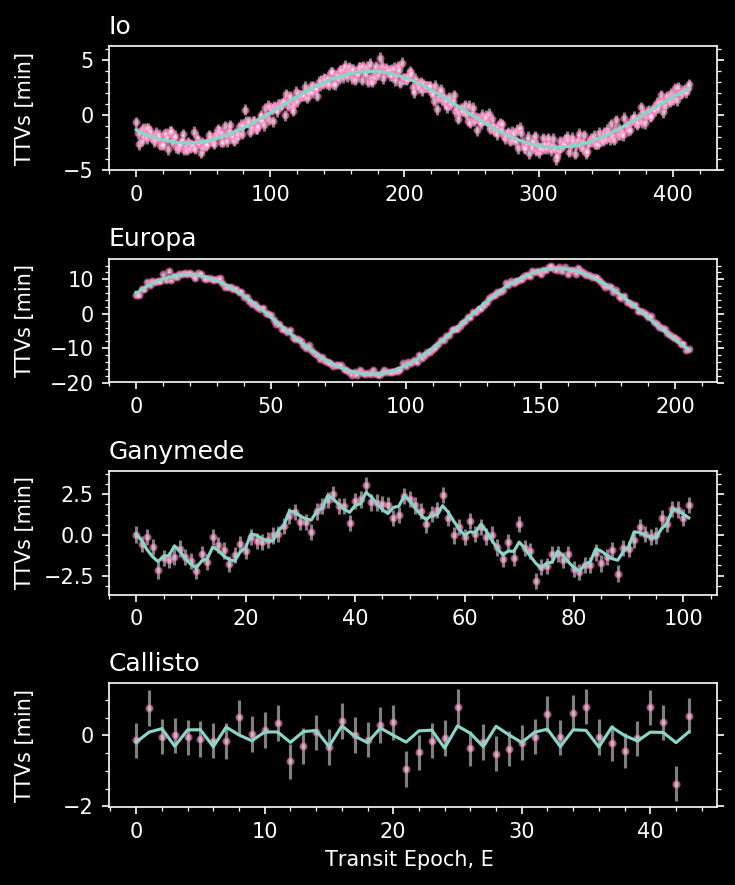

In [84]:
plot_comp(tt,tt0,ttmodel,epochs,[nt1,nt2,nt3,nt4])

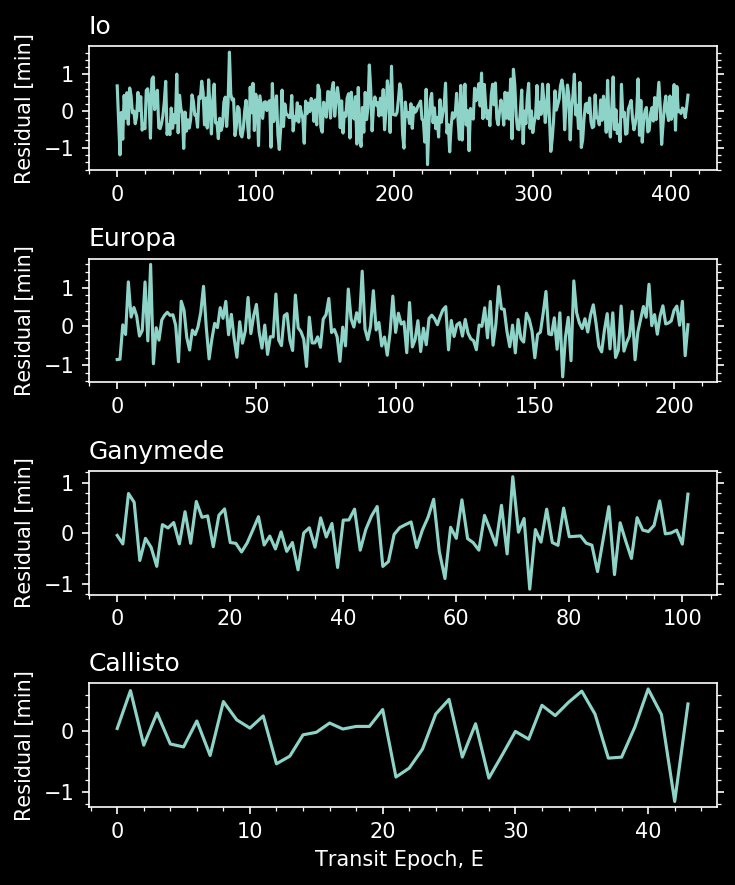

In [85]:
plot_res(tt,ttmodel,[nt1,nt2,nt3,nt4])

## Do global fit

In [86]:
fit = curve_fit((tt0,params) -> new_wrapper(tt0,4,[nt1,nt2,nt3,nt4],params,jmax),tt0,tt,weight,fitted_param)
cov=estimate_covar(fit)
nparam=20
Nobs=sum([nt1,nt2,nt3,nt4])
err=[sqrt(cov[i,j]) for i=1:nparam, j=1:nparam if i==j ]
best_s4 = fit.param ##### is this the global p2 fit???
ttmodel_global = ttv_wrapper(tt0,4,[nt1,nt2,nt3,nt4],best_s4,jmax,true)
lprob_best_s4= (1 - Nobs/2) * log(sum((tt-ttmodel).^2 ./sigtt.^2))
# println("Finished 2-planet fit") 
println("New 4-moon chi-square: ",chisquare(tt0,4,[nt1,nt2,nt3,nt4],best_s4,tt,sigtt,jmax))
println("Maximum: ",lprob_best_s4," Param: ",best_s4)

New 4-moon chi-square: 697.4271094454479
Maximum: -2497.832339154549 Param: [0.00010889328032298237, 1.7691379326784136, 1.376131115144384, -0.0002850807926667969, 0.0012423107544919723, 2.7649082850079688e-5, 3.5511811007621454, 1.5715054139497764, 0.0009707593477381093, 0.003303088737938682, 8.428576241841986e-5, 7.154553960086175, 3.7544798712296426, 0.0039303852981230035, 0.009246755719435498, 5.521983328393051e-5, 16.689047441920724, 9.79826341144936, 0.01119906231236957, 0.02717170100877328]


## Run affine invariant markov chain

In [107]:
fitfile=string("galileo_4moon_fit_noprior_2yrs_full.jld2")
p=jldopen(String(fitfile),"r")

JLDFile /Users/bethleelindor/work/washington/jup_moons/galileo_4moon_fit_noprior_2yrs_full.jld2 (read-only)
 ├─🔢 fit
 ├─🔢 cov
 ├─🔢 lprob_best_s4
 ├─🔢 tt
 ├─🔢 tt0
 └─🔢 sigtt

In [109]:
p["fit"].param

20-element Vector{Float64}:
  0.00010889328032298237
  1.7691379326784136
  1.376131115144384
 -0.0002850807926667969
  0.0012423107544919723
  2.7649082850079688e-5
  3.5511811007621454
  1.5715054139497764
  0.0009707593477381093
  0.003303088737938682
  8.428576241841986e-5
  7.154553960086175
  3.7544798712296426
  0.0039303852981230035
  0.009246755719435498
  5.521983328393051e-5
 16.689047441920724
  9.79826341144936
  0.01119906231236957
  0.02717170100877328

In [127]:
include("gal_mc.jl")

MCMC (generic function with 2 methods)

In [128]:
# testing 
nwalkers = 60
nsteps = 10
foutput=string("galileo_4moon_mcmc_2yrs_full.jld2")
MCMC(foutput,best_s4,lprob_best_s4,
    nsteps,nwalkers,
    4,[nt1,nt2,nt3,nt4],
    p["tt0"],p["tt"],p["sigtt"])

20 parameters from fit: [0.00010889328032298237, 1.7691379326784136, 1.376131115144384, -0.0002850807926667969, 0.0012423107544919723, 2.7649082850079688e-5, 3.5511811007621454, 1.5715054139497764, 0.0009707593477381093, 0.003303088737938682, 8.428576241841986e-5, 7.154553960086175, 3.7544798712296426, 0.0039303852981230035, 0.009246755719435498, 5.521983328393051e-5, 16.689047441920724, 9.79826341144936, 0.01119906231236957, 0.02717170100877328]
Maximum log Prob from fit: -2497.832339154549
No Walkers: 60 No. steps: 10
Burn-in Number (ends): 10


In [129]:
mc = jldopen(foutput,"r")

JLDFile /Users/bethleelindor/work/washington/jup_moons/galileo_4moon_mcmc_2yrs_full.jld2 (read-only)
 ├─🔢 par_mcmc
 ├─🔢 lprob_mcmc
 ├─🔢 param
 ├─🔢 nwalkers
 ├─🔢 nsteps
 ├─🔢 iburn
 ├─🔢 chn
 └─🔢 pname

In [130]:
mc["par_mcmc"]

60×10×21 Array{Float64, 3}:
[:, :, 1] =
 0.000108783  0.000108783  0.000108808  …  0.000108836  0.000108836
 0.000108964  0.000108854  0.000108914     0.000108925  0.000108925
 0.000108814  0.000108903  0.000108903     0.000108905  0.000108905
 0.000108881  0.000108881  0.000108925     0.000108933  0.000108933
 0.000108958  0.000108958  0.000108957     0.000108949  0.000108931
 0.00010874   0.00010874   0.00010874   …  0.00010882   0.00010882
 0.000108963  0.00010895   0.00010895      0.000108937  0.000108879
 0.000108851  0.000108855  0.000108855     0.000108855  0.000108867
 0.000108848  0.000108848  0.000108848     0.000108876  0.000108896
 0.00010879   0.00010879   0.00010885      0.000108862  0.000108862
 0.00010893   0.00010893   0.00010893   …  0.000108962  0.000108962
 0.000108907  0.000108907  0.00010892      0.000108858  0.000108858
 0.000108889  0.000108889  0.000108889     0.000108882  0.000108882
 ⋮                                      ⋱               
 0.000109031  0.0001

In [2]:
using NbodyGradient
fitted_param=[0.00010889328032298237, 1.7691379326784136, 1.376131115144384, -0.0002850807926667969, 0.0012423107544919723, 2.7649082850079688e-5, 3.5511811007621454, 1.5715054139497764, 0.0009707593477381093, 0.003303088737938682, 8.428576241841986e-5, 7.154553960086175, 3.7544798712296426, 0.0039303852981230035, 0.009246755719435498, 5.521983328393051e-5, 16.689047441920724, 9.79826341144936, 0.01119906231236957, 0.02717170100877328]
function get_ic(data)
stara=Elements(m=1.0, P=0.0  ,    
    t0=0.0   ,
    ecosω=0.0  ,  
    esinω=0.0  , 
    I=0.0   ,
    Ω=0.0)
io=Elements(m=data[1],P=data[2],t0=data[3],ecosω=data[4],esinω=data[5] ) 
eur=Elements(m=data[6],P=data[7],t0=data[8],ecosω=data[9],esinω=data[10] ) 
gan=Elements(m=data[11],P=data[12],t0=data[13],ecosω=data[14],esinω=data[15] ) 
cal=Elements(m=data[16],P=data[17],t0=data[18],ecosω=data[19],esinω=data[20] ) 
t0=0.0; tmax=100.0;h=1.0
ic=ElementsIC(t0,5,[stara;io;eur;gan;cal])
intr=Integrator(h,t0,tmax)
return ic
end
ic=get_ic(fitted_param)
s=State(ic)
s.x

3×5 Matrix{Float64}:
 -6.95925e-6   0.0281854   -0.0163154  0.010223   0.0630119
 -1.25258e-5  -0.00508235   0.0423917  0.0712271  0.106914
  0.0          0.0          0.0        0.0        0.0

- Save fit to 4 moons for full 2 yrs of data

In [455]:
@save "galileo_4moon_fit_noprior_2yrs_full.jld2" fit cov lprob_best_s4 tt tt0 sigtt

### Find resonances
Resonances are identified by looking at the resonant arguments, which are defined as: 
   $$ \theta = (p + q)\lambda_{\rm out} - p \lambda_{\rm in} - q \omega_{\rm out/in}$$
 where $\lambda_{\rm out}$ and $\lambda_{\rm in}$ are the mean longitudes of the outer and inner bodies, respectively,
 and $\omega_{\rm out}$ is the longitude of pericenter of the outer/inner body.
 The ratio of periods is defined as : $$P_{\rm in}/P_{\rm out} ~= p / (p + q)$$

 If the resonant argument, $\theta$, oscillates but is constrained within some range of angles, then 
 there is a resonance between the inner and outer bodies. We call this libration of the angle $\theta$. 
 The trick is to find what the values of q and p are.  For our case, we can easily see that 
 there are two 2:1 resonances between the moons, so their resonant arguments would follow 
 the function:
    $$\theta = 2 \lambda_{\rm out} - \lambda_{\rm in} - \omega_{\rm out}$$

 To make the plotting easier, we can borrow this helper function that puts angles into 0 to 360 degrees 
 from another example (Fourier analysis & resonances), and define a new one that puts angles
 into -180 to 180 degrees.

In [82]:
function zeroTo360(val)
    while val < 0
        val += 2*pi
    end
    while val > 2*pi
        val -= 2*pi
    end
    return (val*180/pi)
end

function min180To180(val)
    while val < -pi
        val += 2*pi
    end
    while val > pi
        val -= 2*pi
    end
    return (val*180/pi)
end                

min180To180 (generic function with 1 method)

In [125]:
println("α:")
for i =1:4
    for j = i:4
        if i != j
        println(obj_names[i],"-",obj_names[j]," α: ",(per[i]/per[j]).^(2/3))
    end
end
end

α:
Io-Eur α: 0.6284347140144558
Io-Gan α: 0.39396062472058185
Io-Cal α: 0.22398571736685532
Eur-Gan α: 0.6268918885844992
Eur-Cal α: 0.3564184351561823
Gan-Cal α: 0.5685484876203506


In [3]:
GRAV = 1.327e11 # km^3 / Msun/s^2
sma(T,mstar,mpl) = (T^2 * (mstar + mpl)* GRAV / 4π^2)^(1/3)
for i=1:4
   a=sma(fitted_param[(i-1)*5+2].*24*3600,0.00095,fitted_param[(i-1)*5+1].*0.00095)./AU
    @show a
end

LoadError: UndefVarError: sma not defined

Can compute mean longitudes from TTVFaster, but how to get the longitude of the pericenters? 
- Use Nbody Gradient ?
- compute elements from position vectors, - $\varpi = \Omega + \omega $
- For now, just use the $\omega$ from the fitted results to solve for p and q? note: using fitted masses so plots not truth

In [88]:
function convert_to_elements(x::Vector{T}, v::Vector{T}, mstar::T, m_pl::T, t::T) where T <: AbstractFloat
    R = norm(x)
    v2 = dot(v, v)
    hvec = cross(x, v)
    h = norm(hvec)
    GRAV=1.3275e11 
    Gm = (mstar+m_pl)*GRAV # km3/s2/Msun
    # (2.134)
    a = 1. / (2/R - v2/Gm)
    # (2.135)
    e = sqrt(1 - h^2 / (Gm * a))
    # (2.136)
    hx,hy,hz=hvec
    I = acos(clamp(hz / h, -1, 1))
    # (2.137)
    hz >= 0.0 ? hy *= -1 : hx *= -1
    sinΩ = hx / (h * sin(I))
    cosΩ = hy / (h * sin(I))
    Ω = atan(sinΩ, cosΩ)
    # (2.138)
    sin_ω_plus_f = x[3] / (R * sin(I))
    cos_ω_plus_f = (1 / cos(Ω)) * (x[1] / R + sin(Ω) * sin_ω_plus_f * cos(I))
    ω_plus_f = atan(sin_ω_plus_f, cos_ω_plus_f)
    # (2.139) assuming Rdot = (x.v)/R which is projection of velocity in radial direction
    sinf = a * (1 - e^2) * dot(x, v) / (h * e * R)
    cosf = (1 / e) * (a * (1 - e^2) / R - 1)
    f = atan(sinf, cosf) 
    ω = ω_plus_f - f
    # (2.140)
    # Step 1: Solve for E explicitly from Eq. (2.42)
    cosE = (a - R) / (a * e)
    E = acos(clamp(cosE, -1, 1))
    # Adjust E based on radial velocity
    Rdot = dot(x, v) / R
    if Rdot < 0
        E = 2π - E
    end

    #  Mean anomaly M from Eq. (2.51)
    M = E - e * sin(E)
    #  Mean motion n from Eq. (2.26)
    n_mean = sqrt(Gm / a^3)
    P = 2π/n_mean
    # True longitude from Eq. (2.118)
    ϖ = Ω + ω
    θ = ϖ + f
    #  τ from M and n (Eq. 2.51 rearranged)
    τ = t - M / n_mean
    # Mean longitude, λ from Eq. (2.53)
    λ =  n_mean * (t - τ)
    return (
        a = a/AU, # in astronomical units
        e = e,
        I = I,
        Ω = mod2pi(Ω),
        ω = mod2pi(ω),
        f = mod2pi(f),
        M = mod2pi(M),
        E = mod2pi(E),
        τ = τ/24/3600, # in day
        n = n_mean*24*3600, # per day
        P = P/24/3600, # in days
        λ = λ,
        θ = θ,
        h = h # in 
    )
end

convert_to_elements (generic function with 1 method)

In [238]:
mmr_angle(p,q,λ_out,λ_in,ω_out_in)= (p+q)*λ_out - p * λ_in - q * ω_out_in
per_ratio_sol(x,P_in,P_out) = (x[1] + x[2])  * P_in - x[1] * P_out

per_ratio_sol (generic function with 1 method)

In [ ]:
# angles = zeros(3,jdsize)
#         λ_in =elems_in.λ
#         λ_out=elems_out.λ
# #         if do_outer_long
#             ω_out_in = elems_in.ω
   
# #         else
# #             ω_out_in = elems_in.ω
# #         end
#       angle
# s[:,i].=λ_in,λ_out, ω_out_in #mmr_angle(p,q,λ_out,λ_in,ω_out_in)
# #     end
#             μ_out = fitted_param[(j-1)*5+1]
#             μ_in = fitted_param[(j-2)*5+1]
#             elems_out  = convert_to_elements(pos[:,j,i],vel[:,j,i],
#             0.000955,μ_out.*0.000955,times[i])
#             elems_in  = convert_to_elements(pos[:,j-1,i],vel[:,j-1,i],
#             0.000955,μ_in.*0.000955,times[i])
# #             push!(e,elems_in.e)
#     end
# end

In [176]:
ecc=zeros(4,jdsize);varpi=zeros(4,jdsize);lon=zeros(4,jdsize)
smas = zeros(4,jdsize)
# per_ratio = zeros(4,jdsize)

for j=1:4
    μ = fitted_param[(j-1)*5+1]
    println(μ)
    for i=1:jdsize
         elems = convert_to_elements(pos[:,j,i],vel[:,j,i],
            0.000955,μ.*0.000955,times[i])
        ecc[j,i]=elems.e
        varpi[j,i] = elems.Ω + elems.ω
        lon[j,i]=elems.ω
        smas[j,i] = elems.a
    end
end

2.359305509464093e-6
8.377921327142363e-7
3.563999315661013e-8
9.100209519436697e-8


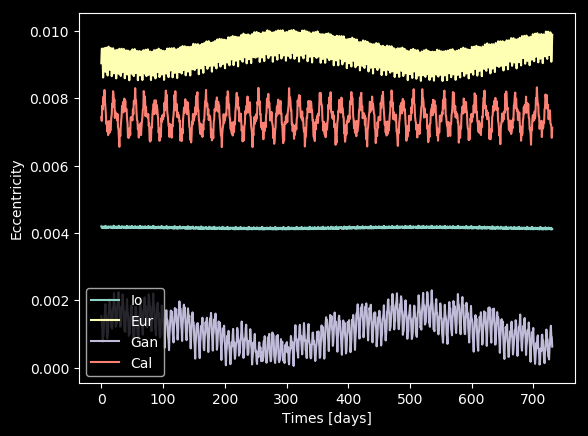

In [158]:
function plot_el(elem)
    fig,(ax)=subplots(1)
# ax.set_prop_cycle(co_cycle)
    for j=1:4
        ax.plot(times.-times[1],elem[j,:],label=obj_names[j])
    end
        ax.set_xlabel("Times [days]");ax.legend()
    return ax
end
ax=plot_el(ecc)
ax.set_ylabel("Eccentricity");

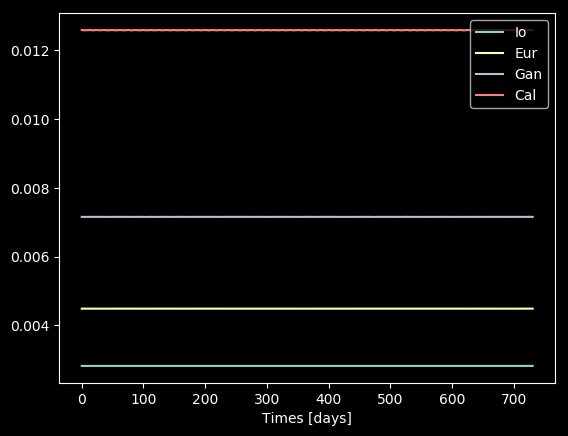

PyObject <matplotlib.axes._subplots.AxesSubplot object at 0x7fbbff20f438>

In [177]:
plot_el(smas)

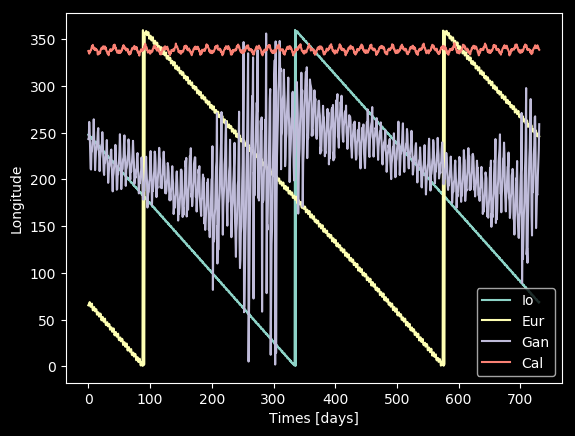

In [159]:
ax2=plot_el(rad2deg.(lon))
ax2.set_ylabel("Longitude");

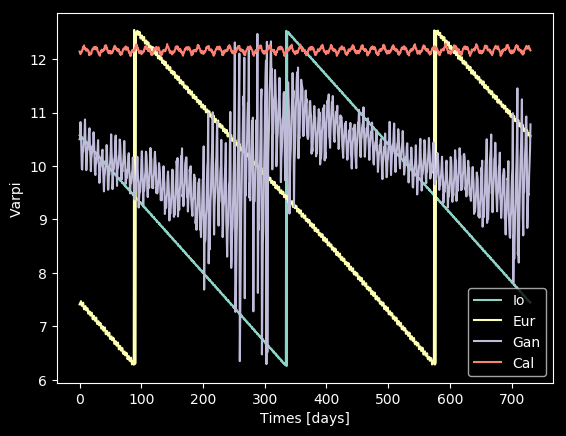

In [175]:
ax2=plot_el((varpi))
ax2.set_ylabel("Varpi");

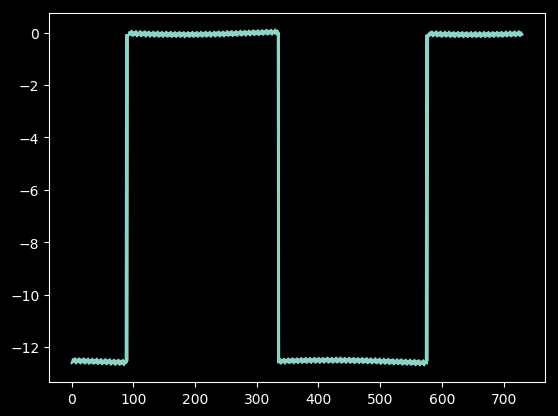

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fbbfb4d86d8>

In [160]:
theta = (2 .* lon[2,:] .- lon[1,:] .- varpi[1,:])
plot(collect(times).-times[1],theta)

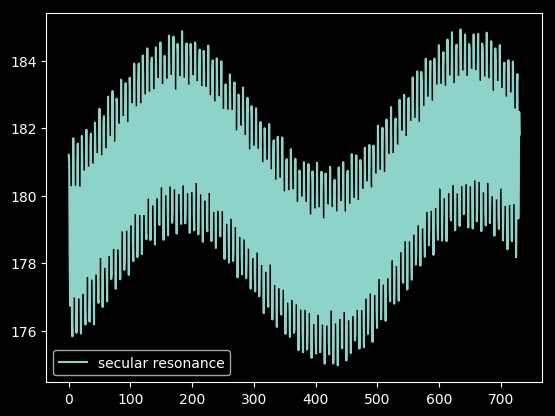

PyObject <matplotlib.legend.Legend object at 0x7fbbfa7687b8>

In [162]:
# theta = min180To180.(2 .* lon[2,:] .- lon[1,:] .- varpi[1,:])
# plot(collect(times).-times[1],theta)
theta_sec = zeroTo360.(-varpi[2,:] .+ varpi[1,:])
plot(collect(times).-times[1],theta_sec,label="secular resonance")
# ylim(-180,360)
legend()

In [149]:
mmr_angle(p,q,λ_out,λ_in,ω_out_in)= (p+q)*λ_out - p * λ_in - q * ω_out_in
function mmr_angle(x,angles)
    n=size(angles,2)
    y=zeros(n)
    for i in 1:n
        λ2,λ1,ω12=angles[1,i],angles[2,i],angles[3,i]
        y[i]=(x[1].+x[2]).* λ2 .- (x[1] .* λ1 ).- x[2] .* ω12
    end
    return y
end

mmr_angle (generic function with 2 methods)

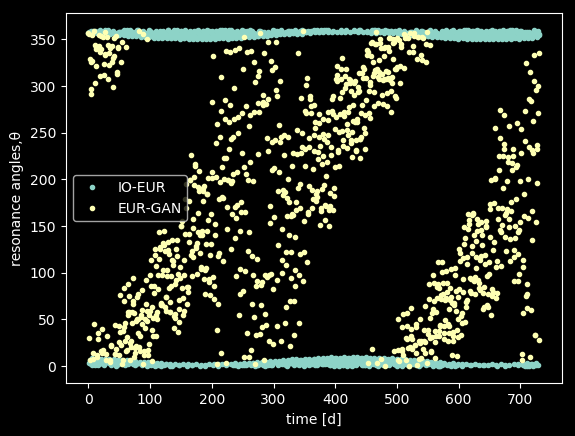

PyObject <matplotlib.legend.Legend object at 0x7fbbfd320ac8>

In [172]:
plot(times.-times[1],zeroTo360.(mmr_angle.(1.0,1.0,lon[2,:],lon[1,:],varpi[1,:])),
    ".",label="IO-EUR")
plot(times.-times[1],zeroTo360.(mmr_angle.(1.0,1.0,lon[3,:],lon[2,:],varpi[2,:])),
    ".",label="EUR-GAN")
xlabel("time [d]")
ylabel("resonance angles,θ")
legend()

In [370]:
using NbodyGradient

┌ Info: Precompiling NbodyGradient [69f646f0-5709-4f35-9e52-1656edff0883]
└ @ Base loading.jl:1342


In [61]:
function compute_λ!(jmax::Integer,p1::TTVFaster.Planet_plane_hk{T},p2::TTVFaster.Planet_plane_hk{T},time1::Vector{T},time2::Vector{T},
            ttv1::Vector{T},ttv2::Vector{T},
            lam1::Vector{T},lam2::Vector{T}) where T<:Real
  # Compute the semi-major axis ratio of the planets:
  # println(p1.period,p2.period)
  alpha = (p1.period/p2.period)^(2//3)  
  #println(alpha, p1.period, p2.period)
  @assert(alpha < 1)
  @assert(alpha > 0)
  # Number of times:
   ntime1 = length(time1)
   ntime2 = length(time2)
  f1=zeros(T,jmax+2,5)  
  f2=zeros(T,jmax+2,5)  
  # Compute the coefficients:
  TTVFaster.ttv_succinct!(jmax+1,alpha,f1,f2)  # I need to compute coefficients one higher than jmax
  # Compute TTVs for inner planet (equation 33):
  # Compute since of \pomegas:
  e1 = sqrt(p1.esinw*p1.esinw + p1.ecosw*p1.ecosw)
  e2 = sqrt(p2.esinw*p2.esinw + p2.ecosw*p2.ecosw)
  sin1om=p1.esinw/e1
  sin2om=p2.esinw/e2
  cos1om=p1.ecosw/e1
  cos2om=p2.ecosw/e2
  # Compute mean motions:
  n1=2pi/p1.period
  n2=2pi/p2.period
  # Compute initial longitudes:
  lam10=-n1*p1.trans0 + 2*p1.esinw # 2*p1.eccen*sin1om
  lam20=-n2*p2.trans0 + 2*p2.esinw # 2*p2.eccen*sin2om
  @inbounds for i=1:ntime1
  # Compute the longitudes of the planets at times of transit of planet 1 (equation 49):
    lam11 = n1*time1[i]+lam10
    lam21 = n2*time1[i]+lam20
    psi1  = lam11-lam21 # Compute difference in longitudes at times of transit of planet 1
    sinpsi1=sin(psi1)
    cospsi1=cos(psi1)
    sinlam11 = sin(lam11)
    coslam11 = cos(lam11)
    sinlam1om1=sinlam11*cos1om - coslam11*sin1om
    coslam1om1=coslam11*cos1om + sinlam11*sin1om
    sinlam1om2=sinlam11*cos2om - coslam11*sin2om
    coslam1om2=coslam11*cos2om + sinlam11*sin2om
    ttv1[i]=zero(T) #0.0
    sinjm1psi1=zero(T) #0.0
    cosjm1psi1=one(T) #1.0
  # Sum over j:
    for j=1:jmax
      sinjpsi1=sinjm1psi1*cospsi1 + cosjm1psi1*sinpsi1
      cosjpsi1=cosjm1psi1*cospsi1 - sinjm1psi1*sinpsi1
      ttv1[i] += f1[j+1,1]*sinjpsi1
      ttv1[i] += f1[j+1,2]*e1*(sinjpsi1*coslam1om1 - cosjpsi1*sinlam1om1)
      ttv1[i] += f1[j+1,3]*e1*(sinjpsi1*coslam1om1 + cosjpsi1*sinlam1om1)
      ttv1[i] += f1[j  ,4]*e2*(sinjpsi1*coslam1om2 - cosjpsi1*sinlam1om2)
      ttv1[i] += f1[j+2,5]*e2*(sinjpsi1*coslam1om2 + cosjpsi1*sinlam1om2)
      sinjm1psi1=sinjpsi1
      cosjm1psi1=cosjpsi1
    end
  # Multiply by period and mass ratio, and divide by 2*Pi:
    ttv1[i] = ttv1[i]*p1.period*p2.mass_ratio/(2pi)
    lam1[i] =  atan(sinlam11, coslam11)
  end
  # Compute TTVs for outer planet (equation 33):
  @inbounds for i=1:ntime2
  # Compute the longitudes of the planets at times of transit of planet 2:
    lam12 = n1*time2[i]+lam10
    lam22 = n2*time2[i]+lam20
    sinlam22 = sin(lam22)
    coslam22 = cos(lam22)
    psi2  = lam12-lam22 # Compute difference in longitudes at times of transit of planet 2
    sinpsi2=sin(psi2)
    cospsi2=cos(psi2)
    sinlam2om1=sinlam22*cos1om - coslam22*sin1om
    coslam2om1=coslam22*cos1om + sinlam22*sin1om
    sinlam2om2=sinlam22*cos2om - coslam22*sin2om
    coslam2om2=coslam22*cos2om + sinlam22*sin2om
    ttv2[i]=zero(p2.period) #0.0
    sinjm1psi2=zero(p2.period) #0.0
    cosjm1psi2=one(p2.period) #1.0
  # Sum over j:
    for j=1:jmax
      sinjpsi2=sinjm1psi2*cospsi2 + cosjm1psi2*sinpsi2
      cosjpsi2=cosjm1psi2*cospsi2 - sinjm1psi2*sinpsi2
      ttv2[i] += f2[j+1,1]*sinjpsi2
      ttv2[i] += f2[j+1,2]*e2*(sinjpsi2*coslam2om2 - cosjpsi2*sinlam2om2)
      ttv2[i] += f2[j+1,3]*e2*(sinjpsi2*coslam2om2 + cosjpsi2*sinlam2om2)
      ttv2[i] += f2[j+2,4]*e1*(sinjpsi2*coslam2om1 - cosjpsi2*sinlam2om1)
      ttv2[i] += f2[j  ,5]*e1*(sinjpsi2*coslam2om1 + cosjpsi2*sinlam2om1)
      sinjm1psi2=sinjpsi2
      cosjm1psi2=cosjpsi2
    end
  # Multiply by period and mass ratio, and divide by 2*Pi:
    ttv2[i] = ttv2[i]*p2.period*p1.mass_ratio/(2pi)
    lam2[i] =  atan(sinlam22, coslam22)
  end
return
end

compute_λ! (generic function with 1 method)

In [68]:

function λ_nplanet(nplanet::Int64,jmax::Int64,ntrans::Vector{Int64},
        params::Vector{T}) where T<:Real
      # The ntrans vectors should have length nplanet:
  @assert(length(ntrans)==nplanet)
    ntransmax = maximum(ntrans)
  λs = zeros(T,nplanet,ntransmax)
     @assert(length(params)==5*nplanet)
  @assert(jmax>=1)  
  for iplanet=1:nplanet
  # Each planet should have at least 2 transits:
    @assert(ntrans[iplanet]>=2)
  end
  for iplanet=1:nplanet-1
  # The periods of the planets should be ordered from least to greatest:
    if (params[(iplanet-1)*5+2] >= params[iplanet*5+2])
      return ttv
    end
  end
  for iplanet=1:nplanet-1
    # Create a Planet_plane_hk type for the inner planet:
    p1=Planet_plane_hk(params[(iplanet-1)*5+1],params[(iplanet-1)*5+2],params[(iplanet-1)*5+3],params[(iplanet-1)*5+4],params[(iplanet-1)*5+5])
    # Create an array of times for the inner planet:
    n1 = ntrans[iplanet]
    time1 = collect(p1.trans0 .+ range(0,stop=n1-1,length=n1) .* p1.period)
    # Loop over outer planets:
    for jplanet=iplanet+1:nplanet
        # Create a Planet_plane_hk type for the outer planet:
        p2=Planet_plane_hk(params[(jplanet-1)*5+1],params[(jplanet-1)*5+2],params[(jplanet-1)*5+3],params[(jplanet-1)*5+4],params[(jplanet-1)*5+5])
        # Create an array of times for the outer planet:
        n2 = ntrans[jplanet]
        time2 = collect(p2.trans0 .+ range(0,stop=n2-1,length=n2) .* p2.period)
        # Define arrays to hold the TTVs:
        ttv1=zeros(T,n1)
        ttv2=zeros(T,n2)
        lam1=zeros(T,n1)
        lam2=zeros(T,n2)
        # Call the compute_ttv code which implements equation (33) from Agol & Deck (2016):
        #    println("Calling compute_ttv")
        compute_λ!(jmax,p1,p2,time1,time2,ttv1,ttv2,lam1,lam2)
        #    println("Finished compute_ttv")
              for i=1:n1
                λs[iplanet,i] += lam1[i]
              end
              for i=1:n2
                λs[jplanet,i] += lam2[i]
              end
    end
end
    return λs
end

λ_nplanet (generic function with 1 method)

In [69]:
lam=λ_nplanet(4,5,[nt1,nt2,nt3,nt4],fitted_param)

4×413 Matrix{Float64}:
 0.110661  0.110661  0.110661  0.110661  …  0.110661  0.110661  0.110661
 0.201303  0.201303  0.201303  0.201303     0.0       0.0       0.0
 0.461305  0.461305  0.461305  0.461305     0.0       0.0       0.0
 0.228938  0.228938  0.228938  0.228938     0.0       0.0       0.0

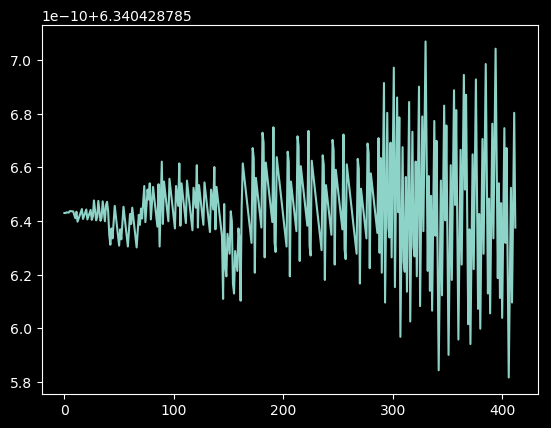

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fbbf9ebd5c0>

In [123]:
plot(min180To180.(lam[1,:]))

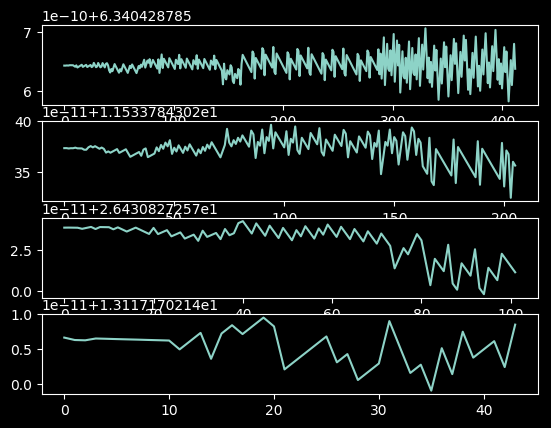

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fbbf64185c0>

In [80]:
fig,axs=subplots(4)
axs[1].plot(rad2deg.(lam[1,:]))
axs[2].plot(rad2deg.(lam[2,1:nt2]))
axs[3].plot(rad2deg.(lam[3,1:nt3]))
axs[4].plot(rad2deg.(lam[4,1:nt4]))

In [66]:
lam[2]

206-element Vector{Float64}:
 0.06710083709708625
 0.06710083709708646
 0.06710083709708443
 0.06710083709708595
 0.06710083709708571
 0.06710083709708903
 0.06710083709708524
 0.06710083709708499
 0.06710083709708474
 0.06710083709707738
 0.06710083709707713
 0.06710083709709111
 0.06710083709709797
 ⋮
 0.06710083709699653
 0.06710083709697498
 0.06710083709695341
 0.06710083709693186
 0.06710083709691028
 0.06710083709711612
 0.06710083709686718
 0.067100837097073
 0.06710083709705145
 0.06710083709680251
 0.06710083709700833
 0.06710083709698675

In [67]:
lam[3]

LoadError: BoundsError: attempt to access Tuple{Vector{Float64}, Vector{Float64}} at index [3]